In [125]:
# https://www.kaggle.com/datasets/thembatman/make-moons-from-sklearn
# Make moons from sklearn
# make_moons.csv

In [126]:
import pandas as pd
from matplotlib import pyplot as plt
import torch
from torch.nn import Linear, Sigmoid
import numpy as np

In [127]:
data = pd.read_csv('make_moons.csv')
print("Первые 5 строк:")
print(data.head())

Первые 5 строк:
          X         Y  label
0 -1.129064 -0.049047      0
1  0.264658  0.960315      0
2  0.604729  0.585562      0
3 -0.603916  0.789943      0
4 -0.591466  0.712346      0


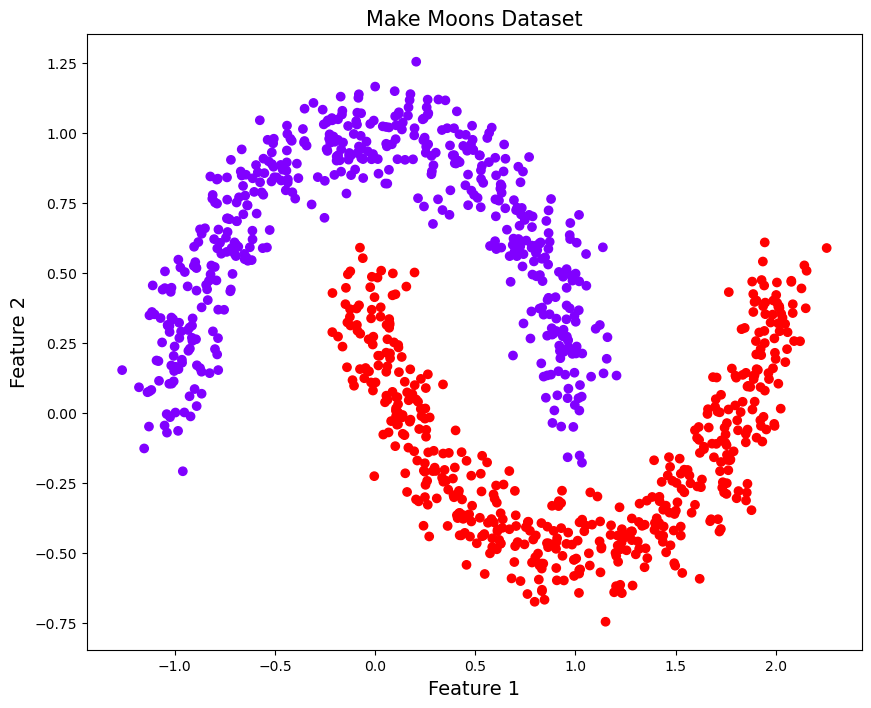

In [128]:
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=data.iloc[:, 2], cmap='rainbow')
plt.title('Make Moons Dataset', fontsize=15)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.show()

In [129]:
X = data.iloc[:, :2].values
y = data.iloc[:, 2].values.reshape((-1, 1))

In [130]:
print(f"Размер X: {X.shape}")
print(f"Уникальные классы: {np.unique(y)}")

Размер X: (1000, 2)
Уникальные классы: [0 1]


In [131]:
num_features = X.shape[1]
neuron = torch.nn.Sequential(
    Linear(num_features, out_features=1),
    Sigmoid()
)
print("\nСтруктура нейрона:")
print(neuron)


Структура нейрона:
Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)


In [133]:
sample = torch.autograd.Variable(torch.FloatTensor(X[0]))
print(f"Предсказание для первого объекта: {neuron(sample).item():.4f}")

Предсказание для первого объекта: 0.6352


In [135]:
X_tensor = torch.autograd.Variable(torch.FloatTensor(X))
proba_pred = neuron(X_tensor)
y_pred = (proba_pred > 0.5).float()
y_pred_np = y_pred.data.numpy().reshape(-1)

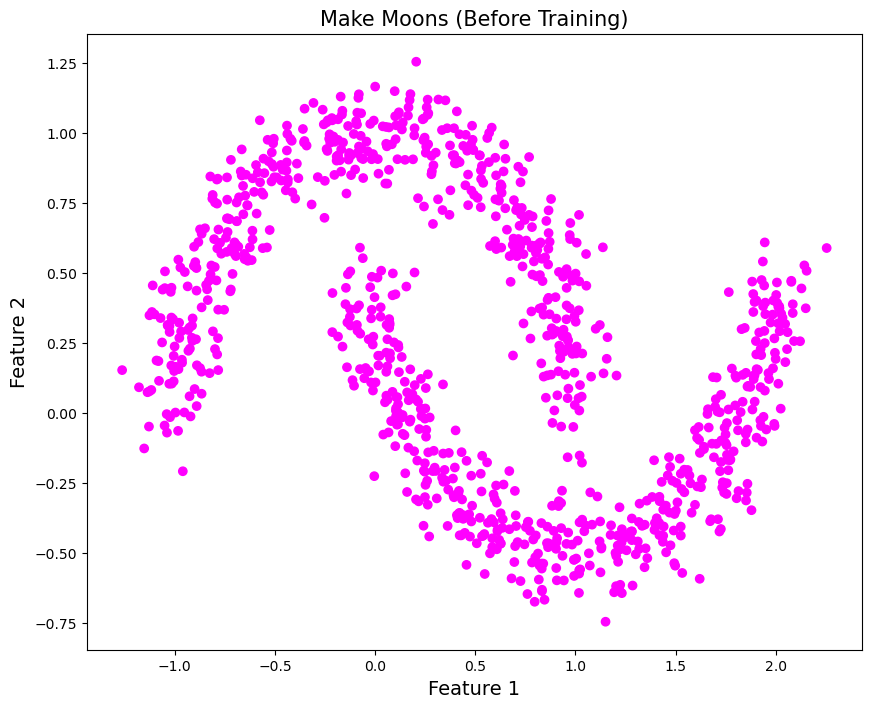

In [136]:
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=y_pred_np, cmap='spring')
plt.title('Make Moons (Before Training)', fontsize=15)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.show()

In [137]:
X_var = torch.autograd.Variable(torch.FloatTensor(X))
y_var = torch.autograd.Variable(torch.FloatTensor(y))

In [138]:
loss_fn = torch.nn.MSELoss(size_average=False)
learning_rate = 0.001
optimizer = torch.optim.SGD(neuron.parameters(), lr=learning_rate)

C:\Users\dsoko\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


In [139]:
print("\nОбучение нейрона:")
for t in range(500):
    y_pred = neuron(X_var)
    loss = loss_fn(y_pred, y_var)
    
    if t % 100 == 0:
        print('Эпоха {}: Loss = {:.4f}'.format(t, loss.item()))
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Обучение нейрона:
Эпоха 0: Loss = 295.0309
Эпоха 100: Loss = 90.6774
Эпоха 200: Loss = 84.7533
Эпоха 300: Loss = 82.8840
Эпоха 400: Loss = 82.0541


In [140]:
with torch.no_grad():
    proba_pred = neuron(X_var)
    y_pred = (proba_pred > 0.5).float()
    y_pred_np = y_pred.numpy().reshape(-1)

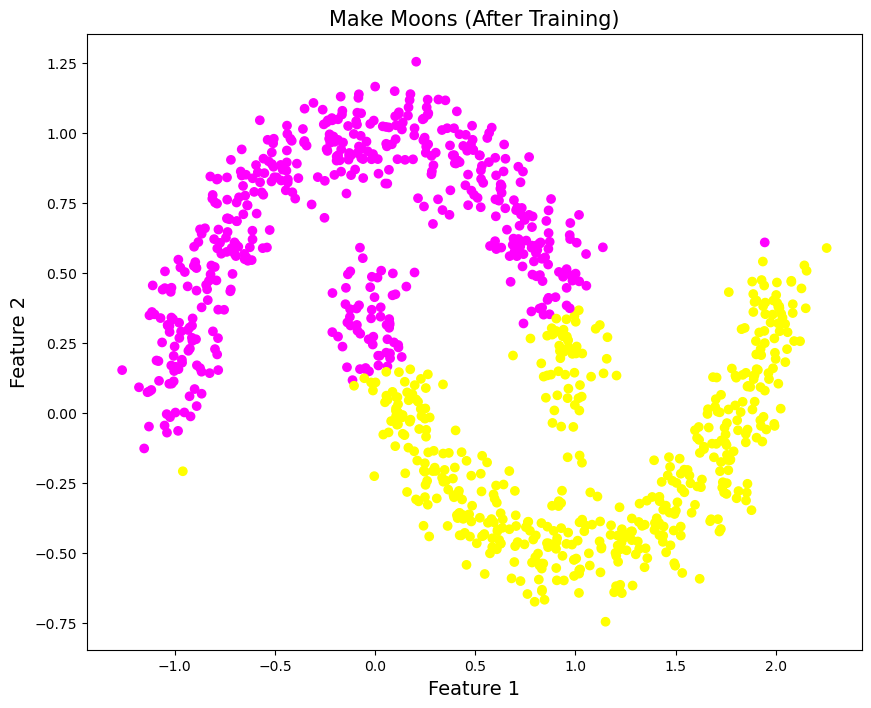

In [141]:
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=y_pred_np, cmap='spring')
plt.title('Make Moons (After Training)', fontsize=15)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.show()

In [142]:
y_true = y.reshape(-1)
accuracy = (y_pred_np == y_true).mean()
print(f"\nТочность модели: {accuracy:.3f} ({accuracy*100:.1f}%)")


Точность модели: 0.881 (88.1%)
